In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('../../cp/results_base2_tfd.csv')
df

,Unnamed: 0.8,config,num_trains,num_expansions,makespan,makespan_pp,search_time,Unnamed: 0.7,Unnamed: 0.6,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0
0,0,13.0,3.0,3420.0,126.0,124.0,290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,13.0,5.0,1127.0,297.0,230.0,281.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,8.0,3.0,58378.0,111.0,111.0,290.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,8.0,4.0,22699.0,186.0,164.0,291.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,8.0,5.0,11448.0,233.0,205.0,290.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,56,4.0,5.0,10699.0,190.0,139.0,90.0,54.0,41.0,31.0,31.0,25.0,22.0,16.0,NaN
57,57,4.0,6.0,17294.0,265.0,269.0,290.0,55.0,42.0,32.0,32.0,26.0,23.0,17.0,NaN
58,58,4.0,7.0,15022.0,400.0,336.0,290.0,56.0,43.0,33.0,33.0,27.0,24.0,18.0,NaN
59,59,4.0,8.0,6660.0,460.0,424.0,290.0,57.0,44.0,34.0,34.0,28.0,25.0,19.0,NaN


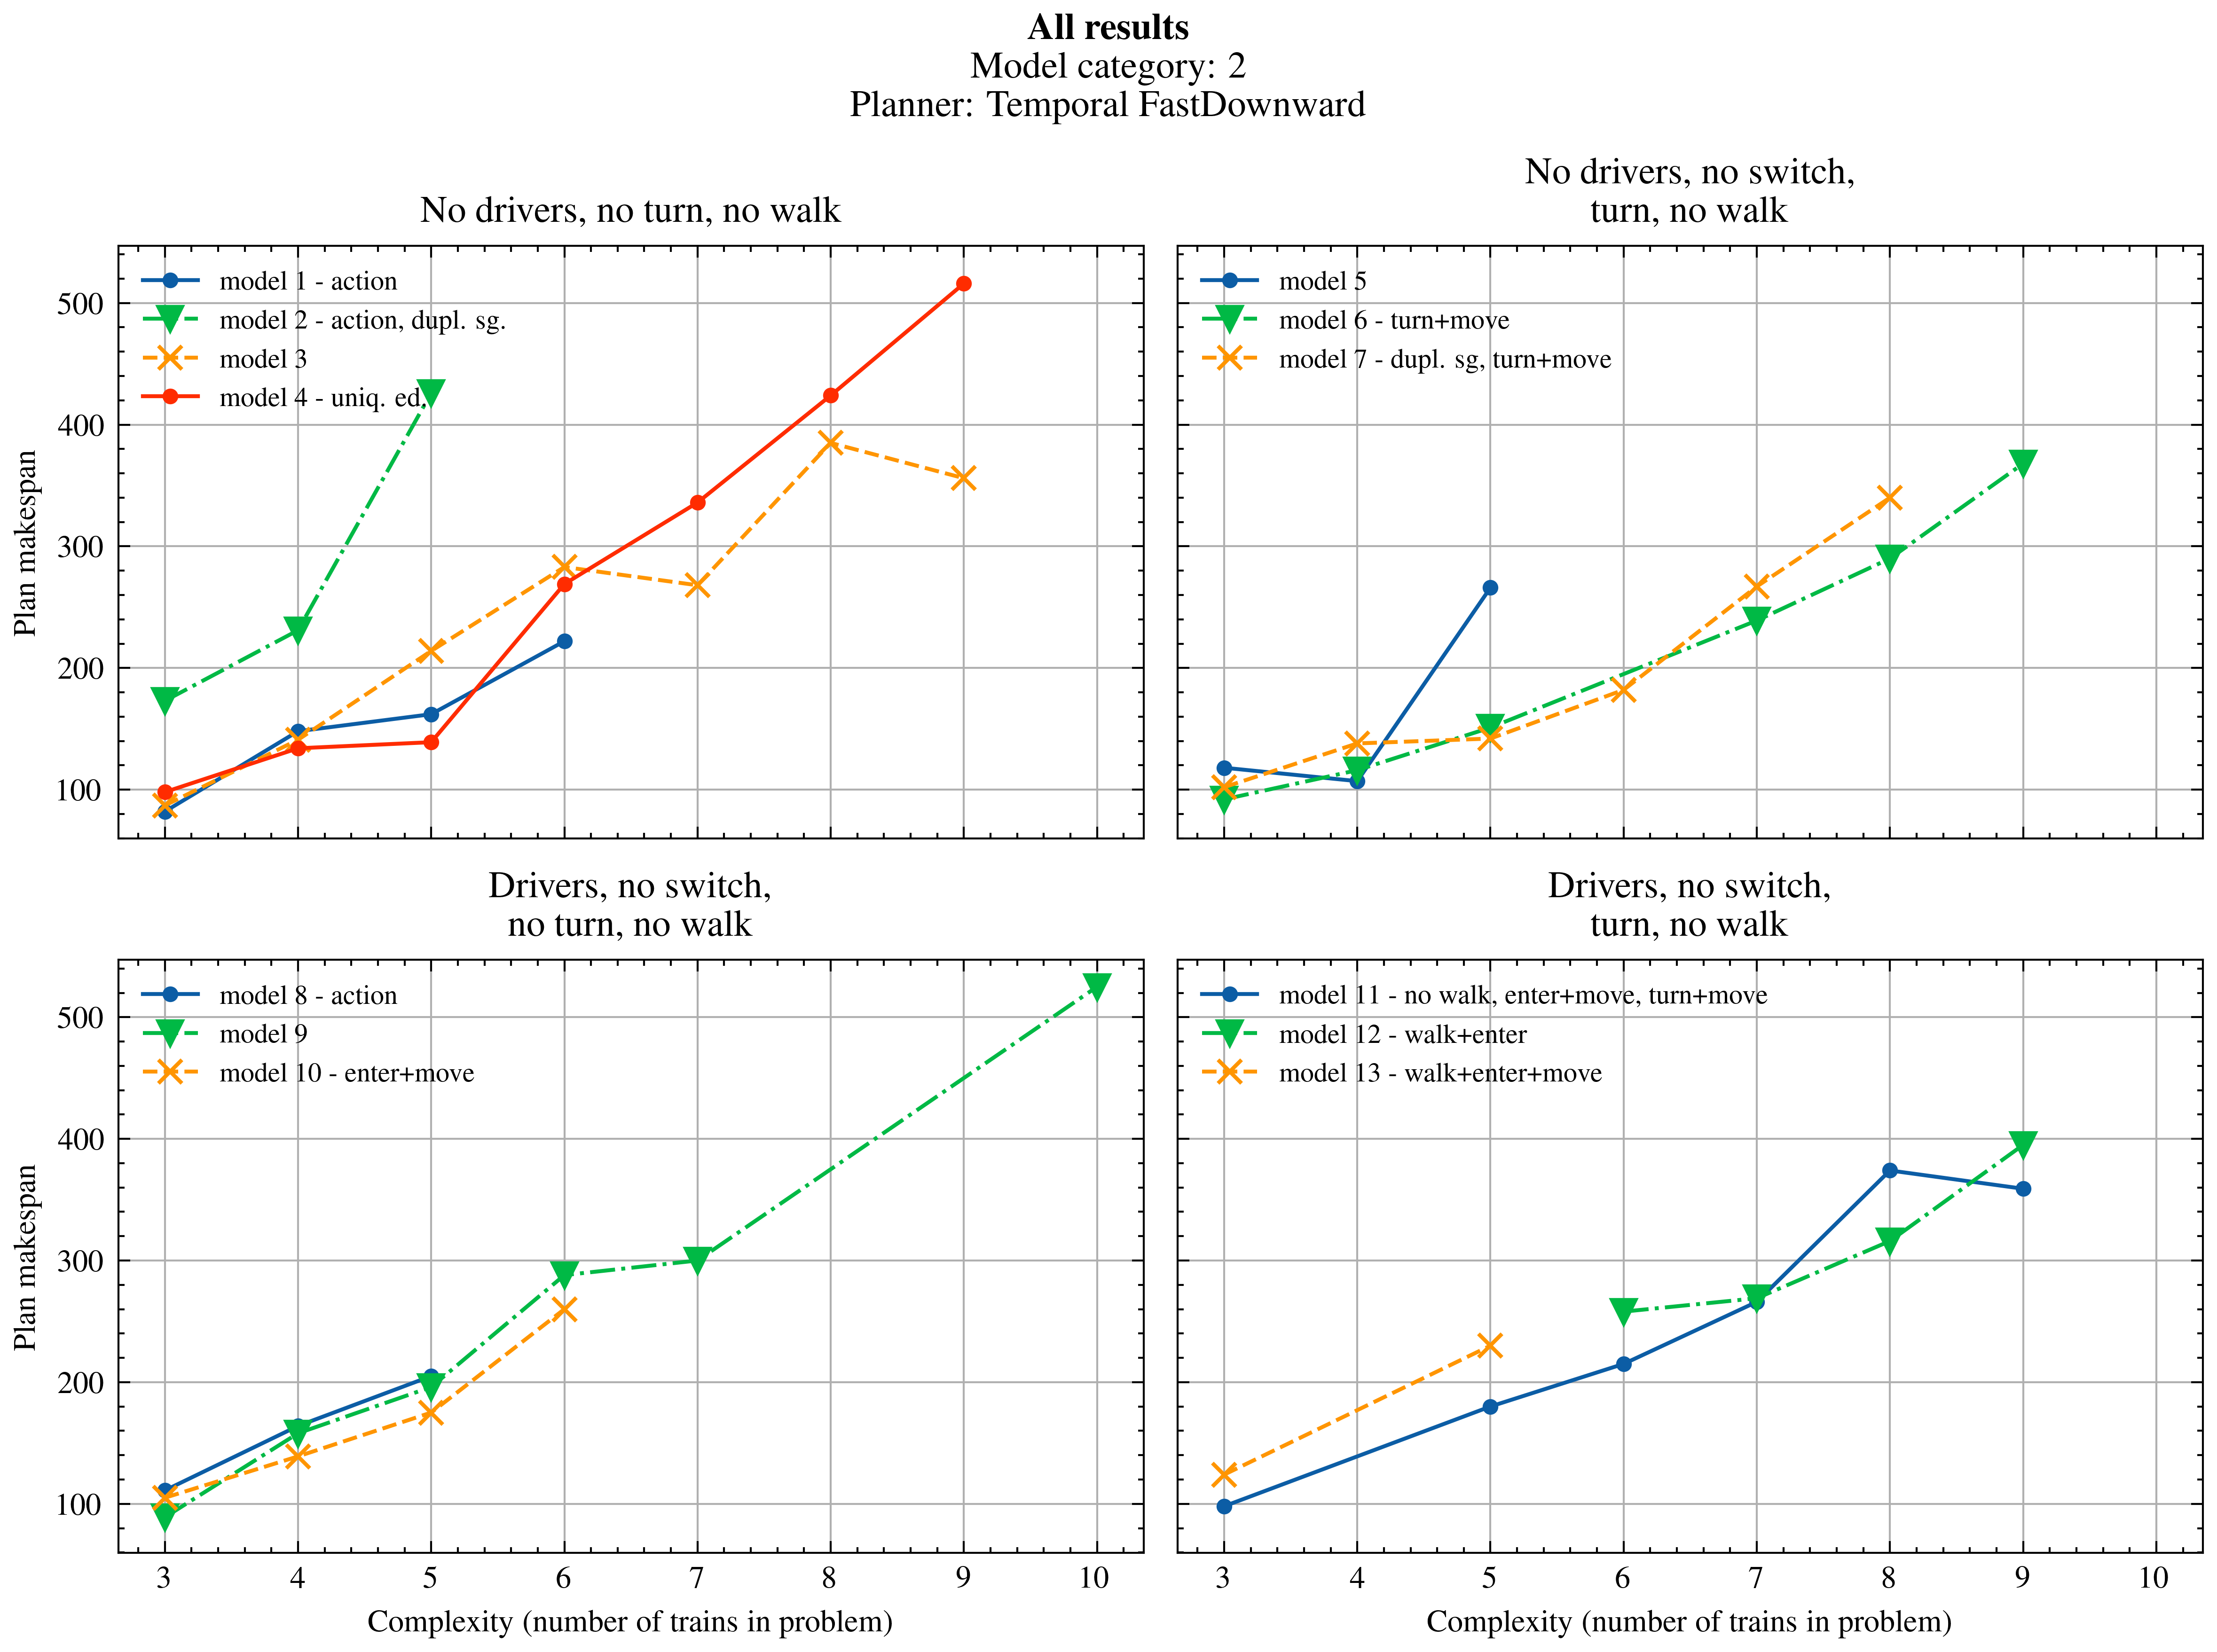

In [3]:
plt.style.use(['ieee', 'science'])

groups = [[1,2,3,4],[5,6,7],[8,9,10],[11,12,13]]
labels = [['- action','- action, dupl. sg.','','- uniq. ed.'],
          ['', '- turn+move', '- dupl. sg, turn+move'],
          ['- action', '', '- enter+move'],
          ['- no walk, enter+move, turn+move', '- walk+enter', '- walk+enter+move'],
          ]
group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(2,2, figsize=(8,6), sharey=True, sharex=True)
ax = ax.flatten()
fig.suptitle(r"""\textbf{All results}
             Model category: 2
             Planner: Temporal FastDownward""")

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        if j % 3 == 0:
            dots = '.-'
        elif j % 3 == 1:
            dots = 'v-.'
        else:
            dots = 'x--'
        ax[i].plot(group_x[i][j], group_y[i][j], dots, label=f'model {groups[i][j]} {labels[i][j]}', linewidth=1)
        ax[i].legend(loc='upper left', fontsize=7)
        ax[i].grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

ax[0].set_ylabel('Plan makespan')
ax[2].set_ylabel('Plan makespan')
ax[2].set_xlabel('Complexity (number of trains in problem)')
ax[3].set_xlabel('Complexity (number of trains in problem)')


ax[0].set_title('No drivers, no turn, no walk')
ax[1].set_title('No drivers, no switch,\n turn, no walk')
ax[2].set_title('Drivers, no switch,\n no turn, no walk')
ax[3].set_title('Drivers, no switch,\nturn, no walk')

fig.tight_layout()
fig.savefig('tfd_base2_makespans.png')


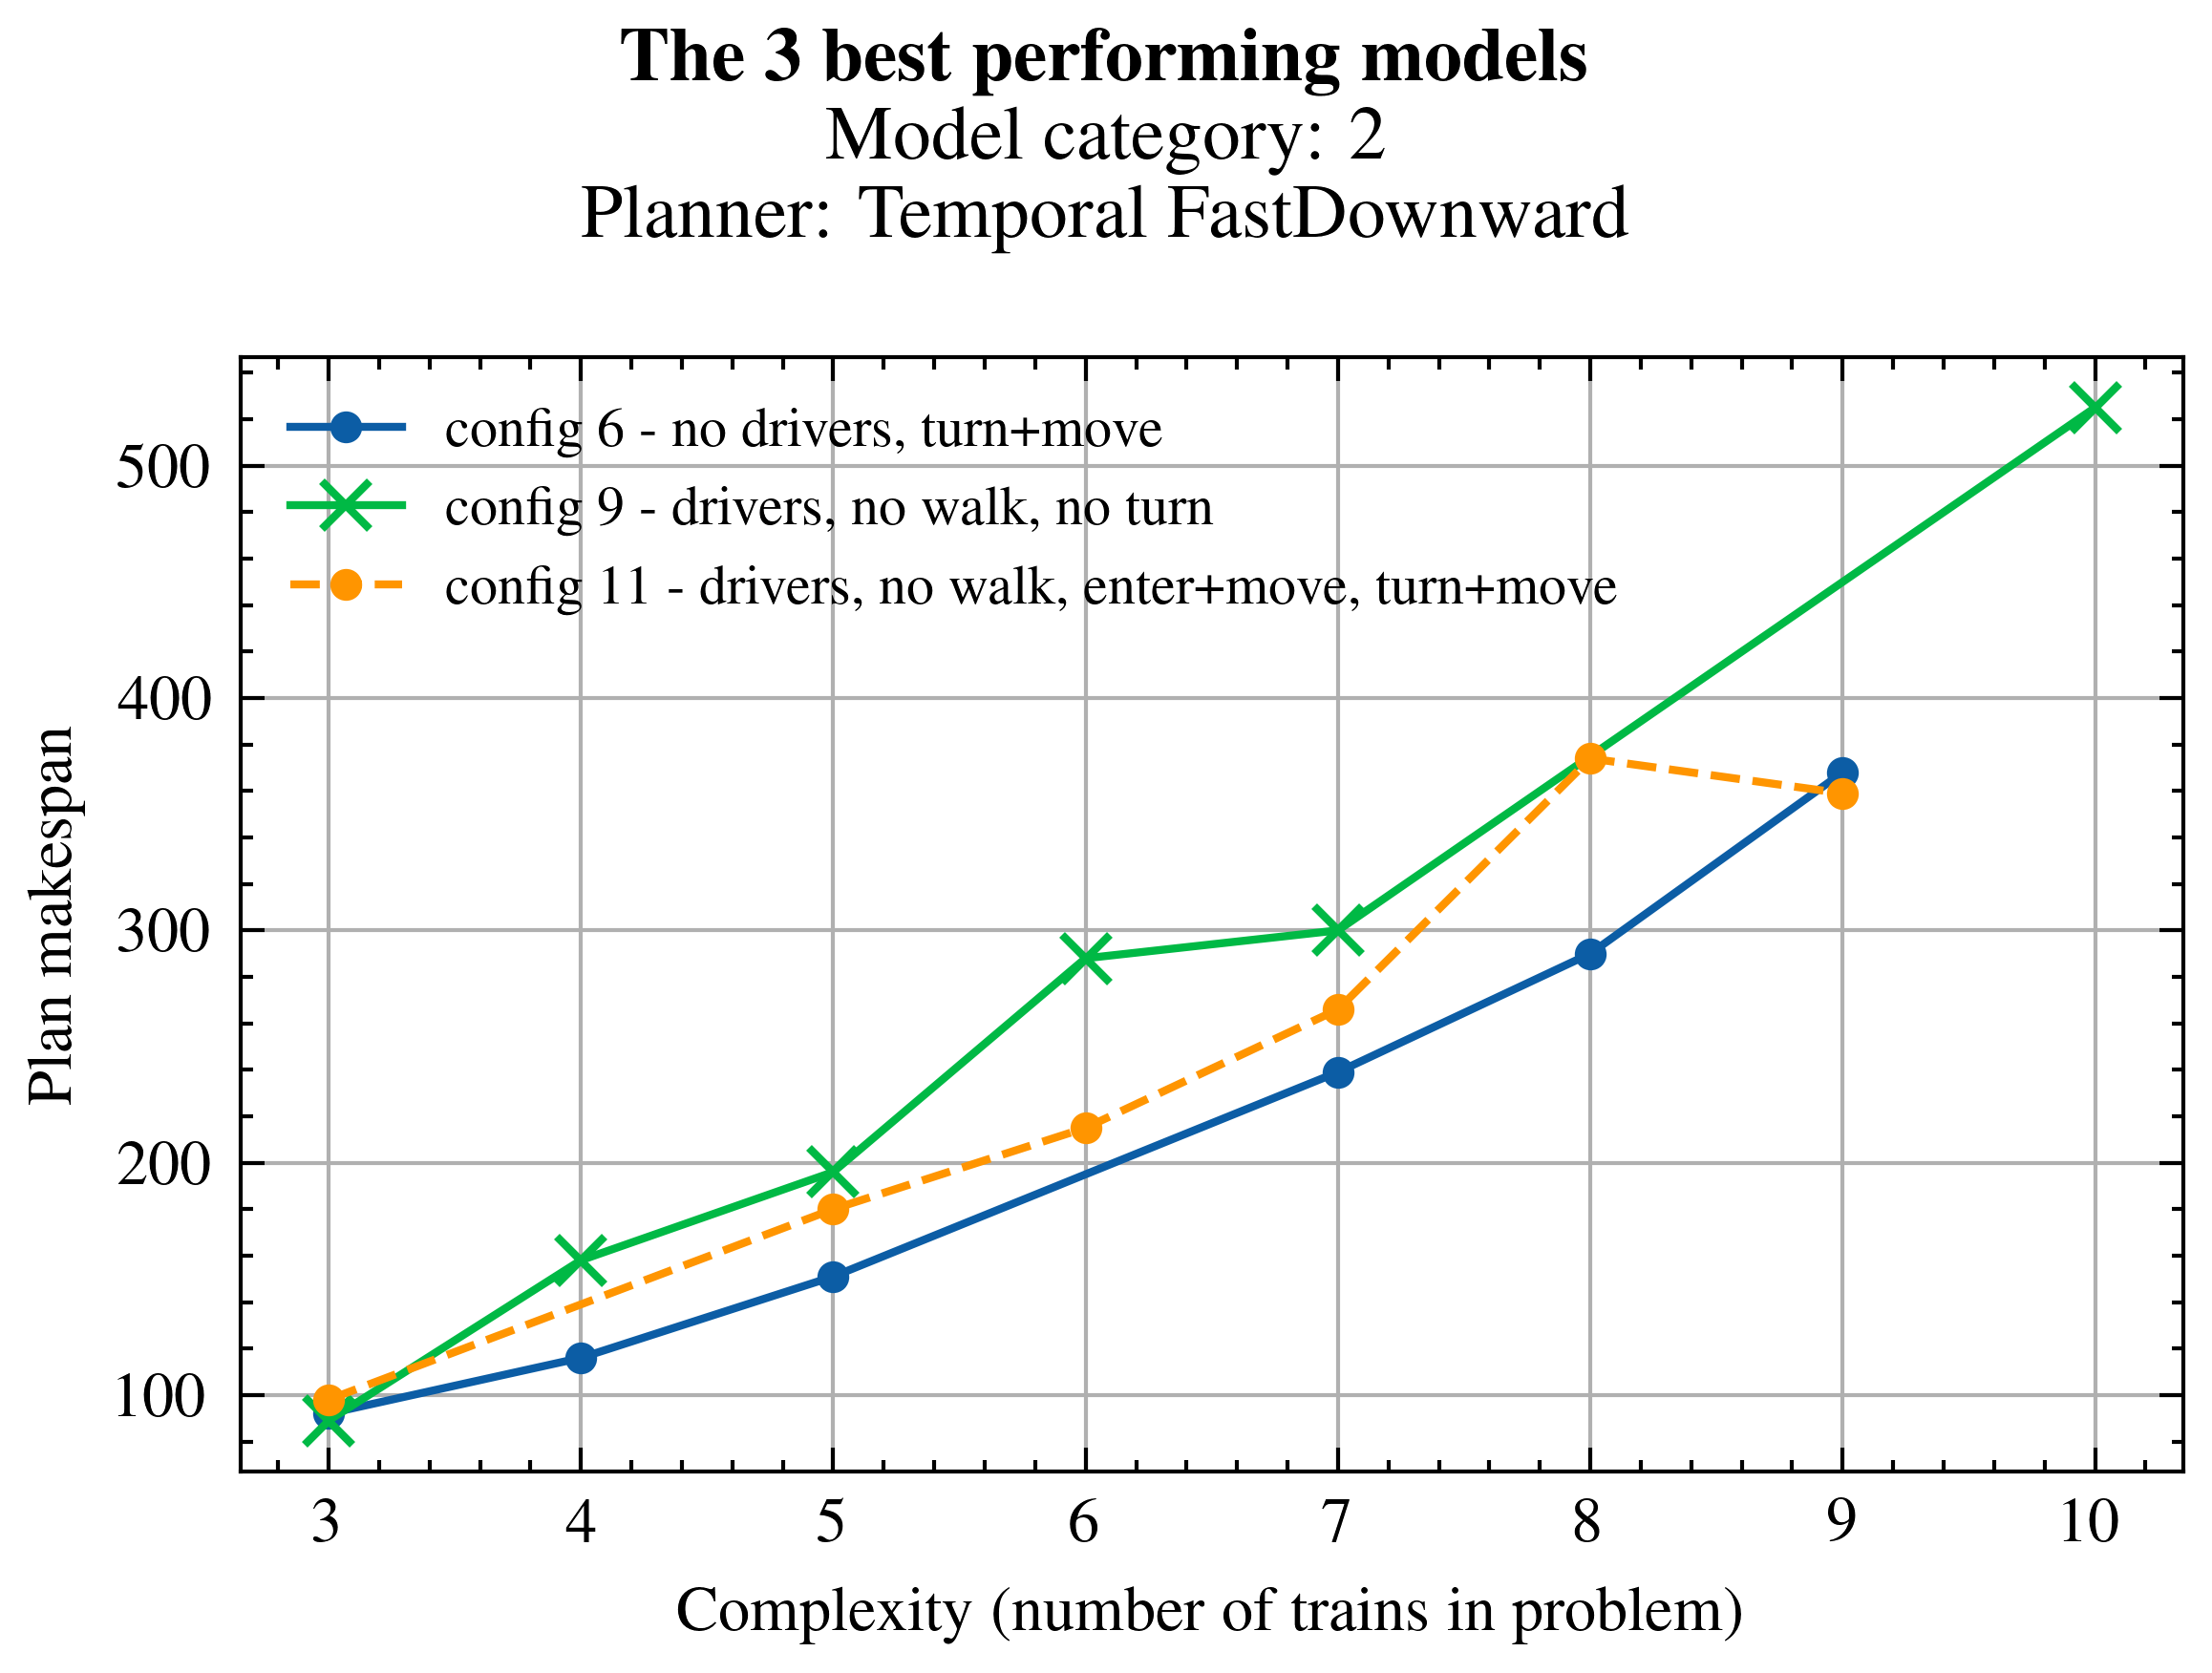

In [4]:
plt.style.use(['ieee', 'science'])

groups = [[6,9,11]]
labels = [
    ['- no drivers, turn+move', '- drivers, no walk, no turn', '- drivers, no walk, enter+move, turn+move']
]

group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(1,1, figsize=(4,3), sharey=True, sharex=True)
# ax = ax.flatten()
fig.suptitle(r"""\textbf{The 3 best performing models}
             Model category: 2
             Planner: Temporal FastDownward""")

configs = ['.-', 'x-', '.--', 'x--']

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        ax.plot(group_x[i][j], group_y[i][j], configs[j], label=f'config {groups[i][j]} {labels[i][j]}', linewidth=1)
        ax.legend(loc='upper left', fontsize=7)
        ax.grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylabel('Plan makespan')
ax.set_xlabel('Complexity (number of trains in problem)')

fig.tight_layout()
fig.savefig('tfd_base2_makespans_pp.png')
